In [2]:
# --- Cell 1: Imports ---
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# --- Cell 2: Load & Clean Data ---
print("=" * 65)
print("STEP 1: Loading & Cleaning Data")
print("=" * 65)

df1 = pd.read_csv('D:\\ML CODES\\IBM\\Train_Cleaned\\Airline_train_cleaned.csv')
df2 = pd.read_csv('D:\\ML CODES\\IBM\\Train_Cleaned\\text.tweeet_cleaned.csv')
df3 = pd.read_csv('D:\\ML CODES\\IBM\\Train_Cleaned\\train_cleaned.csv')
df4 = pd.read_csv('D:\\ML CODES\\IBM\\Train_Cleaned\\train_tweet_cleaned.csv')

df = pd.concat([df1, df2, df3, df4], ignore_index=True)

# --- Data Cleaning ---
print(f"Before cleaning: {df.shape[0]} rows")

# Drop duplicates
df.drop_duplicates(inplace=True)

# Drop null values
df.dropna(subset=['text', 'sentiment'], inplace=True)

# Remove empty strings and whitespace-only texts
df = df[df['text'].str.strip().astype(bool)].copy()

# Strip extra whitespace from text
df['text'] = df['text'].astype(str).str.strip()

# Standardize sentiment labels (handle case inconsistency)
df['sentiment'] = df['sentiment'].str.strip().str.capitalize()

print(f"After cleaning:  {df.shape[0]} rows\n")
print(f"Label Distribution:")
print(df['sentiment'].value_counts())
print(f"\nLabel Proportions:")
print(df['sentiment'].value_counts(normalize=True).round(4))

STEP 1: Loading & Cleaning Data
Before cleaning: 105463 rows
After cleaning:  105137 rows

Label Distribution:
sentiment
Positive    49825
Negative    38137
Neutral     17175
Name: count, dtype: int64

Label Proportions:
sentiment
Positive    0.4739
Negative    0.3627
Neutral     0.1634
Name: proportion, dtype: float64


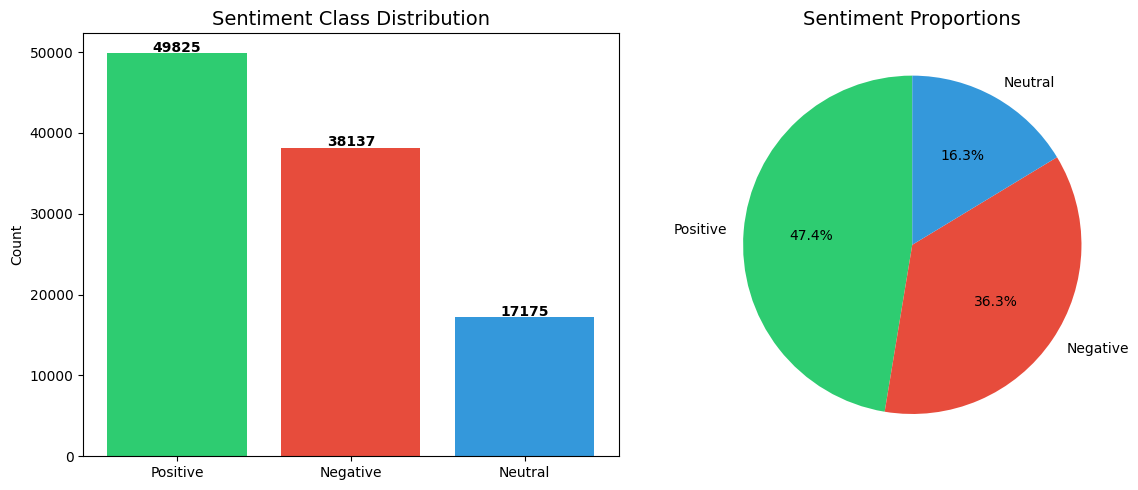

In [4]:
# --- Cell 3: Visualize class distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = df['sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Sentiment Class Distribution', fontsize=14)
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 200, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Sentiment Proportions', fontsize=14)

plt.tight_layout()
plt.show()

In [5]:
# --- Cell 4: Train / Test Split ---
print("=" * 65)
print("STEP 2: Train / Test Split  (80% train | 20% test)")
print("=" * 65)

X = df['text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print(f"\nTrain label distribution:")
print(y_train.value_counts())

STEP 2: Train / Test Split  (80% train | 20% test)
Training samples : 84,109
Test samples     : 21,028

Train label distribution:
sentiment
Positive    39860
Negative    30509
Neutral     13740
Name: count, dtype: int64


In [6]:
# --- Cell 5: Build Pipeline with class_weight='balanced' ---
print("=" * 65)
print("STEP 3: Building Pipeline  (TF-IDF → LinearSVC)")
print("=" * 65)

pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                sublinear_tf=True,
                strip_accents="unicode",
                analyzer="word",
                token_pattern=r"\w{2,}",
            ),
        ),
        (
            "clf",
            LinearSVC(
                max_iter=10000,
                random_state=42,
                dual="auto",
                class_weight="balanced",   # KEY FIX: handles class imbalance
            ),
        ),
    ]
)

print("Pipeline created successfully.")
print("  class_weight='balanced' → automatically adjusts for imbalanced classes\n")

STEP 3: Building Pipeline  (TF-IDF → LinearSVC)
Pipeline created successfully.
  class_weight='balanced' → automatically adjusts for imbalanced classes



In [7]:
# --- Cell 6: Define Hyperparameter Grid ---
print("=" * 65)
print("STEP 4: Hyperparameter Grid")
print("=" * 65)

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_df"     : [0.85, 0.90, 0.95],
    "tfidf__min_df"     : [1, 2, 3],
    "clf__C"            : [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],   # Wider range for better tuning
}

total_combos = np.prod([len(v) for v in param_grid.values()])
print(f"Total combinations: {total_combos}")
print(f"With 5-fold CV: {total_combos * 5} fits\n")

for param, values in param_grid.items():
    print(f"  {param:<30} {values}")

STEP 4: Hyperparameter Grid
Total combinations: 108
With 5-fold CV: 540 fits

  tfidf__ngram_range             [(1, 1), (1, 2)]
  tfidf__max_df                  [0.85, 0.9, 0.95]
  tfidf__min_df                  [1, 2, 3]
  clf__C                         [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]


In [ ]:
# --- Cell 7: Run GridSearchCV ---
print("=" * 65)
print("STEP 5: Running GridSearchCV  (5-fold Stratified CV)")
print("This may take several minutes ...")
print("=" * 65)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2,
    refit=True,
)

start_time = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f"\nGridSearchCV completed in {elapsed / 60:.1f} minutes.")

STEP 5: Running GridSearchCV  (5-fold Stratified CV)
This may take several minutes ...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [ ]:
# --- Cell 8: Best Parameters ---
print("=" * 65)
print("STEP 6: Best Hyperparameters Found")
print("=" * 65)

best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

for param, value in best_params.items():
    print(f"  {param:<30} {value}")

print(f"\n  Best CV F1-macro score : {best_cv_score:.4f}")

In [ ]:
# --- Cell 9: Top 10 Hyperparameter Combinations ---
cv_results = pd.DataFrame(grid_search.cv_results_)
top10 = cv_results.nsmallest(10, 'rank_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].reset_index(drop=True)

print("Top 10 Hyperparameter Combinations:")
print(top10.to_string(index=False))

In [ ]:
# --- Cell 10: Evaluate on Test Set ---
print("=" * 65)
print("STEP 7: Evaluation on Test Set")
print("=" * 65)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Individual metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall    = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1        = f1_score(y_test, y_pred, average="macro", zero_division=0)

# Also calculate weighted versions (more forgiving with imbalance)
precision_w = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall_w    = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1_w        = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"\n  {'Metric':<25} {'Macro':>10} {'Weighted':>10}")
print(f"  {'─'*45}")
print(f"  {'Accuracy':<25} {accuracy:>10.4f} {accuracy:>10.4f}")
print(f"  {'Precision':<25} {precision:>10.4f} {precision_w:>10.4f}")
print(f"  {'Recall':<25} {recall:>10.4f} {recall_w:>10.4f}")
print(f"  {'F1 Score':<25} {f1:>10.4f} {f1_w:>10.4f}")

# Per-class report
print(f"\n{'─'*65}")
print("Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

In [ ]:
# --- Cell 11: Confusion Matrix ---
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Print as DataFrame
print("Confusion Matrix (rows=Actual | cols=Predicted):")
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print(cm_df.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)

# Normalized (percentages per row)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized %)', fontsize=14)

plt.suptitle('KIKO - Sentiment Analysis Results', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# --- Cell 12: Per-class F1 Bar Chart ---
from sklearn.metrics import f1_score as f1_per_class

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
class_f1 = {label: report[label]['f1-score'] for label in labels}

plt.figure(figsize=(8, 5))
bars = plt.bar(class_f1.keys(), class_f1.values(), color=['#e74c3c', '#3498db', '#2ecc71'])
plt.title('F1 Score Per Class', fontsize=14)
plt.ylabel('F1 Score')
plt.ylim(0, 1)
for bar, val in zip(bars, class_f1.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.4f}",
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Identify weakest class
weakest = min(class_f1, key=class_f1.get)
print(f"⚠ Weakest class: '{weakest}' with F1 = {class_f1[weakest]:.4f}")

In [ ]:
# --- Cell 14: Quick Prediction Test ---
def predict_sentiment(text):
    """Predict sentiment for a single text input."""
    pred = best_model.predict([text])[0]
    return pred

test_texts = [
    "I love this airline, best service ever!",
    "Terrible experience, never flying again.",
    "The flight was okay, nothing special.",
    "You are absolutely disgusting and horrible.",
    "Thank you for helping me today!",
]

print("=" * 65)
print("Real-Time Predictions")
print("=" * 65)
for text in test_texts:
    sentiment = predict_sentiment(text)
    emoji = {"Positive": "😊", "Negative": "😡", "Neutral": "😐"}.get(sentiment, "❓")
    print(f"  {emoji} [{sentiment:>8}]  →  \"{text}\"")

print("\nDone. ✅")